In [2]:
# repo en la branch del lab4 https://github.com/donmatthiuz/VIC/tree/lab4
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('1.png')
img2 = cv2.imread('2.png')

In [8]:
# funciones
def detectar_y_emparejar(img1, img2):
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.9 * n.distance:
            good_matches.append(m)

    pts_src = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts_dst = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    return kp1, kp2, good_matches, pts_src, pts_dst

def get_normalization_matrix(pts):
    mean = np.mean(pts, axis=0)
    std = np.std(pts)
    T = np.array([[1.0/std, 0, -mean[0]/std],
                  [0, 1.0/std, -mean[1]/std],
                  [0, 0, 1]])
    return T

def calcular_homografia_dlt(src_pts, dst_pts):
    T_src = get_normalization_matrix(src_pts);
    T_dst = get_normalization_matrix(dst_pts);

    src_n = cv2.perspectiveTransform(src_pts.reshape(-1, 1, 2), T_src).reshape(-1, 2);
    dst_n = cv2.perspectiveTransform(dst_pts.reshape(-1, 1, 2), T_dst).reshape(-1, 2);

    A = []
    for i in range(len(src_n)):
        x, y = src_n[i];
        xp, yp = dst_n[i];
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp]);
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp]);

    U, S, Vt = np.linalg.svd(np.array(A));
    H_n = Vt[-1].reshape(3, 3);

    H = np.linalg.inv(T_dst) @ H_n @ T_src;
    return H / H[2, 2];

def ransac_homografia(pts_src, pts_dst, umbral=5.0, prob_exito=0.99):
    max_inliers = []
    best_H = None
    N = 1000 # solo es valor inicial, mas abajo se calcula N segun lo que vimos en clase
    iteracion = 0
    total = len(pts_src)

    while iteracion < N:
        idx = np.random.choice(total, 4, replace=False)
        try:
            H_test = calcular_homografia_dlt(pts_src[idx], pts_dst[idx])
        except:
            iteracion += 1
            continue

        proj = cv2.perspectiveTransform(pts_src.reshape(-1, 1, 2), H_test).reshape(-1, 2)
        dist = np.linalg.norm(pts_dst - proj, axis=1)
        inliers = np.where(dist < umbral)[0]

        if len(inliers) > len(max_inliers):
            max_inliers = inliers
            best_H = H_test
            # el calculo de N
            w = len(inliers) / total
            if w > 0 and w < 1.0:
                p_outlier_sample = 1 - w**4
                if p_outlier_sample > 0:
                    N = np.log(1 - prob_exito) / np.log(p_outlier_sample)
                    N = int(N) + 1

        iteracion += 1
        if iteracion > 5000: break

    print(f"RANSAC finalizado: {iteracion} iteraciones, {len(max_inliers)} inliers encontrados.")

    if len(max_inliers) > 4:
        best_H = calcular_homografia_dlt(pts_src[max_inliers], pts_dst[max_inliers])

    return best_H

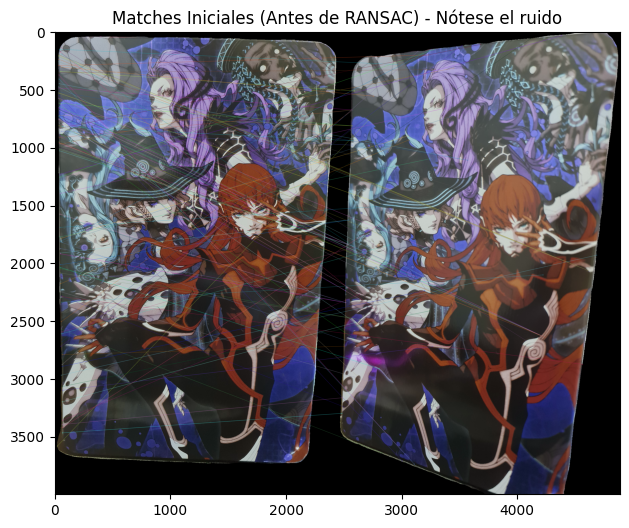

RANSAC finalizado: 827 iteraciones, 2160 inliers encontrados.


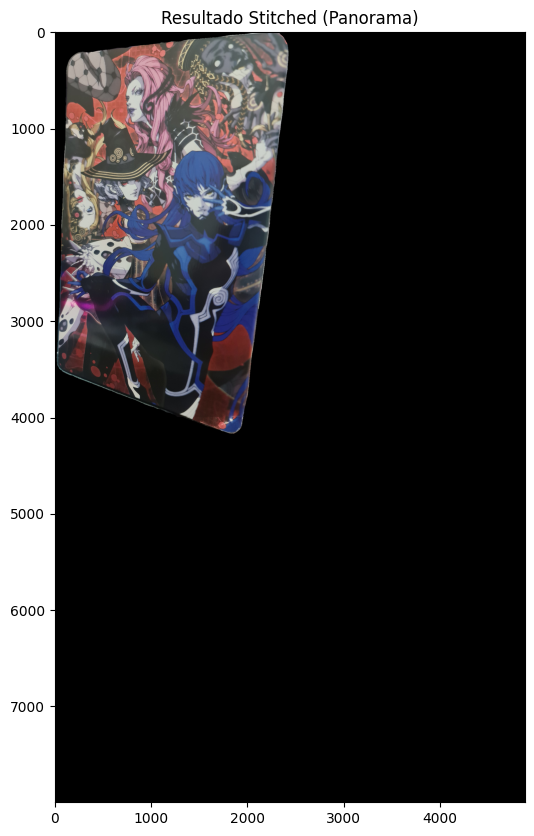

In [9]:
# mostrar resultados
img_ref = cv2.imread('2.png') # destino
img_warp = cv2.imread('1.png') # fuente

# detectar y visualizar
kp_s, kp_d, matches, p_s, p_d = detectar_y_emparejar(img_warp, img_ref)

img_m = cv2.drawMatches(img_warp, kp_s, img_ref, kp_d, matches[:100], None, flags=2)
plt.figure(figsize=(15, 6))
plt.imshow(img_m)
plt.title("Matches Iniciales (Antes de RANSAC) - Nótese el ruido")
plt.show()

#  RANSAC
H_final = ransac_homografia(p_s, p_d)

# Stitching
h, w = img_ref.shape[:2]
pano = cv2.warpPerspective(img_warp, H_final, (w*2, h*2))
pano[0:h, 0:w] = img_ref

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
plt.title("Resultado Stitched (Panorama)")
plt.show()